In [1]:
import sys
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms

# Explicitly define the project root as one level up (../)
project_root = os.path.abspath('..')
src_path = os.path.join(project_root, 'src')

# Forcefully insert these exact paths into Python's system path
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Verify the paths it resolved
print(f"Looking for root in: {project_root}")
print(f"Looking for src in: {src_path}")

# Import your modules
from model import get_model
from config import IMAGE_SIZE

print("\nPaths configured and modules imported successfully!")

Looking for root in: c:\Users\Rald999\Documents\GitHub\chestxray-classification
Looking for src in: c:\Users\Rald999\Documents\GitHub\chestxray-classification\src


c:\Users\Rald999\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Paths configured and modules imported successfully!


In [2]:
# !python -m pip install -r ../requirements.txt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Explicitly pointing to your requested checkpoint directory
model_weights_path = r"../model_checkpoints/raddino_best_model.pth"

print(f"Loading RadDINO from {model_weights_path}...")
model = get_model()
model.load_state_dict(torch.load(model_weights_path, map_location=device))
model.to(device)
model.eval()
print("Model loaded successfully!")

Loading RadDINO from ../model_checkpoints/raddino_best_model.pth...


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 3848.79it/s]


Model loaded successfully!


In [4]:
def compute_rollout(attentions):
    # Create an identity matrix to represent the residual connections
    result = torch.eye(attentions[0].size(-1)).to(attentions[0].device)
    
    for attention in attentions:
        attention_heads_fused = attention.mean(axis=1)
        attention_heads_fused += torch.eye(attention_heads_fused.size(-1)).to(attention.device)
        attention_heads_fused = attention_heads_fused / attention_heads_fused.sum(dim=-1, keepdim=True)
        result = torch.matmul(attention_heads_fused, result)
        
    return result

# Standard validation transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

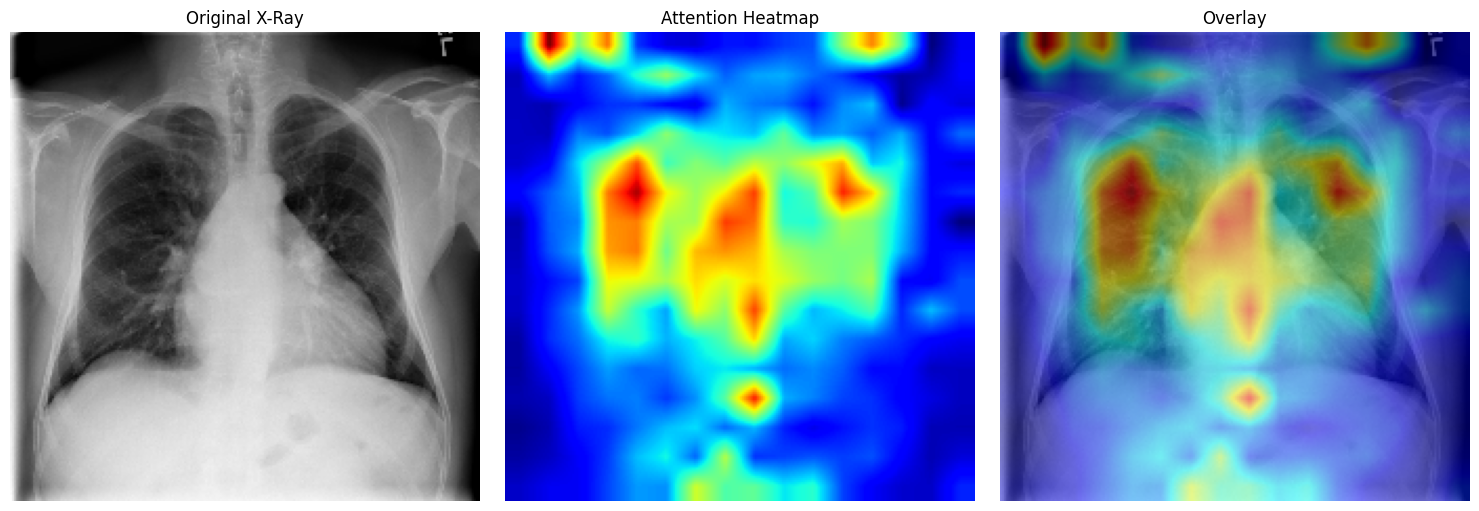

--- Model Predictions ---
Class 1: 0.6868 confidence
Class 3: 0.1063 confidence
Class 2: 0.0850 confidence


In [5]:
# Change this to any X-ray image path in your dataset
image_path = "../dataset/00000001_000.png"

# Load and preprocess image
original_image = cv2.imread(image_path)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
resized_image = cv2.resize(original_image, (IMAGE_SIZE, IMAGE_SIZE))
input_tensor = transform(resized_image).unsqueeze(0).to(device)

# --- THE FIX: Force the Hugging Face config to output attentions ---
model.encoder.config.output_attentions = True
model.encoder.config.return_dict = True

# Forward pass to get attentions and predictions
with torch.no_grad():
    # Pass the image through the encoder
    outputs = model.encoder(input_tensor, output_attentions=True, return_dict=True)
    attentions = outputs.attentions
    
    # Safety Check: Ensure the attentions were successfully captured
    if attentions is None or len(attentions) == 0:
        raise ValueError("Error: The model still refused to return attention weights! Please run '!pip install --upgrade transformers' and restart your kernel.")
    
    cls_token = outputs.pooler_output
    logits = model.classifier(cls_token)
    probs = torch.sigmoid(logits)[0].cpu().numpy()

# Calculate Rollout
rollout = compute_rollout(attentions)
cls_attention = rollout[0, 0, 1:]

# Calculate the grid size (e.g., for 518x518 with patch size 14, this is 37)
grid_size = int(np.sqrt(cls_attention.size(0)))
attention_map = cls_attention.reshape(grid_size, grid_size).cpu().numpy()

# Normalize and format heatmap
attention_map = (attention_map - np.min(attention_map)) / (np.max(attention_map) - np.min(attention_map))
heatmap = cv2.resize(attention_map, (IMAGE_SIZE, IMAGE_SIZE))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
overlay = cv2.addWeighted(resized_image, 0.5, heatmap_color, 0.5, 0)

# Plotting
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Original X-Ray")
plt.imshow(resized_image)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Attention Heatmap")
plt.imshow(heatmap, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis('off')

plt.tight_layout()
plt.show()

print("--- Model Predictions ---")
top_indices = np.argsort(probs)[::-1][:3]
for idx in top_indices:
    print(f"Class {idx}: {probs[idx]:.4f} confidence")